# HATC-IDS — Final Pipeline, Results and Hardware Validation

**Datasets:** Edge-IIoTset and CIC-IIoT-2025.

This notebook runs the **final** model set only — no exploratory sweep, no
superseded architecture variants:

| family | configs kept | why |
|---|---|---|
| **HATC-v3** | `d=8,K=8` and `d=24,K=8` | cheap end + headline; the two points that draw the frontier |
| **MLP** (baseline) | `h=16` and best-per-dataset | cheap end + best; same two roles |
| **classical** | GBDT, LogReg | reference points, seconds to fit |

| part | what it does | needs |
|---|---|---|
| **A. Pipeline** | prep → train → INT8 → per-class → firmware export | GPU (skipped if outputs exist) |
| **B. Results** | tables, Pareto plots, per-class | nothing, reads `results/` |
| **C. Hardware** | parity, latency, energy | ESP32-S3 + arduino-cli |

**Resumable** — every stage checks its own outputs and skips if present; set
`FORCE = True` to re-run. **Safe without hardware** — Part C auto-detects the
board and no-ops if none is attached.

Every model, quantiser, metric and training loop is defined **once**, in
Section 1, and reused by every stage below.

## 0 · Setup

In [1]:
import gc
import math
import os
import subprocess
import sys
import time
import warnings
from dataclasses import dataclass
from typing import Callable, Optional

In [2]:
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

In [3]:
# ---- knobs -----------------------------------------------------------------
DATASETS = ["edge", "cic25", "cicids"]   # the three reported corpora
FORCE = False                  # True = re-run stages even if outputs exist
BOARD_PORT = None              # e.g. "COM6"; None = auto-detect
N_SEEDS = 3
EPOCHS = 25
BATCH_SIZE = 1024
N_BINS = 8
# ----------------------------------------------------------------------------

In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

ARDUINO_CLI = os.path.expanduser("~/tools/arduino-cli/arduino-cli.exe")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEEDS = list(range(N_SEEDS))

os.makedirs("results", exist_ok=True)
os.makedirs("logs", exist_ok=True)

In [5]:
CACHE = {"edge": "data/edge_full.npz", "cic25": "data/cic25_full.npz",
         "cicids": "data/cicids_full.npz"}
LABEL = {"edge": "Edge-IIoTset", "cic25": "CIC-IIoT-2025",
         "cicids": "CICIDS2017"}
RAW = {
    "edge": r"C:/Users/ashis/OneDrive/01_PhD_Research/Publications/dataset/Edge_iiot/DNN-EdgeIIoT-dataset.csv",
    "cic25": r"C:/Users/ashis/OneDrive/01_PhD_Research/Publications/dataset/CICIIOT25",
    # CICIDS2017 has no RAW entry: it runs from cicids_full.npz, which was
    # prepared in the 2026-09-11 session. Rebuilding it from raw would need
    # a preparation cell that this notebook does not contain.
}

In [6]:
def have(path: str) -> bool:
    """True if `path` exists and is non-empty — the stage-skip test."""
    return os.path.exists(path) and os.path.getsize(path) > 0

In [7]:
def stage(name: str, outputs: list[str], fn: Callable[[], None]) -> bool:
    """Run `fn()` unless every path in `outputs` already exists."""
    if not FORCE and all(have(p) for p in outputs):
        print(f"[SKIP] {name}")
        return False
    print(f"[RUN ] {name}")
    fn()
    return True

In [8]:
def log(*args) -> None:
    """Flush-on-write print, so progress shows up during long stages."""
    print(*args, flush=True)

In [9]:
def free_gpu() -> None:
    """Hand GPU memory back between stages."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [10]:
print("python  :", sys.executable)
print("device  :", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU only")
print("arduino :", "found" if have(ARDUINO_CLI) else "MISSING")
for name in DATASETS:
    size = f"({os.path.getsize(CACHE[name]) / 1e6:.1f} MB)" if have(CACHE[name]) else ""
    print(f"  {'OK  ' if have(CACHE[name]) else 'MISS'} {CACHE[name]} {size}")

python  : /Library/Developer/CommandLineTools/usr/bin/python3
device  : cpu | CPU only
arduino : MISSING
  OK   data/edge_full.npz (5.5 MB)
  OK   data/cic25_full.npz (6.8 MB)
  OK   data/cicids_full.npz (28.0 MB)


## 1 · Shared components

Defined **once** here and reused by every stage. In the previous version each
pipeline stage was a standalone script, so these were written out four or five
separate times.

### 1.1 Metrics

In [11]:
def macro_f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

In [12]:
def find_minority_class(classes: list, ytr: np.ndarray) -> int:
    """Index of the class whose recall this study tracks: literal "mitm" if
    the dataset has one, else the rarest class in the training split."""
    for i, cls in enumerate(classes):
        if str(cls).lower() == "mitm":
            return i
    counts = np.bincount(ytr, minlength=len(classes))
    return int(np.argmin(np.where(counts > 0, counts, counts.max() + 1)))

### 1.2 Dataset bundle

One object carrying everything the models need, so no stage re-derives bin
edges or class weights for itself.

In [13]:
@dataclass
class Bundle:
    """A prepared dataset: arrays, GPU tensors, bin indices, class weights."""
    name: str
    classes: list
    N: int
    C: int
    Xtr: np.ndarray; ytr: np.ndarray
    yva: np.ndarray; yte: np.ndarray
    Xt: torch.Tensor; yt: torch.Tensor; Xv: torch.Tensor; Xs: torch.Tensor
    Bt: torch.Tensor; Bv: torch.Tensor; Bs: torch.Tensor
    W: torch.Tensor
    bin_edges: np.ndarray
    Xte: np.ndarray
    minority: int

In [14]:
def inverse_frequency_weights(ytr: np.ndarray, n_classes: int) -> torch.Tensor:
    """Class weights for WCE: total / (C * count), floored at count=1."""
    counts = np.bincount(ytr, minlength=n_classes).astype(np.float64)
    weights = counts.sum() / (n_classes * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

In [15]:
def quantile_bin_edges(Xtr: np.ndarray) -> np.ndarray:
    """N_BINS-quantile cut points per feature, fitted on train only."""
    return np.quantile(Xtr, np.linspace(0, 1, N_BINS + 1)[1:-1], axis=0)


def bin_indices(X: np.ndarray, edges: np.ndarray) -> torch.Tensor:
    """Per-feature bin index in [0, N_BINS-1] for every row of `X`."""
    idx = (X[:, None, :] > edges[None, :, :]).sum(1)
    return torch.tensor(idx, dtype=torch.long, device=DEVICE)

In [16]:
def load_bundle(dataset: str) -> Bundle:
    """Load a prepared .npz cache into a ready-to-train Bundle."""
    npz = np.load(CACHE[dataset], allow_pickle=True)
    Xtr, Xva, Xte = npz["Xtr"], npz["Xva"], npz["Xte"]
    ytr, yva, yte = npz["ytr"], npz["yva"], npz["yte"]
    classes = list(npz["classes"])
    edges = quantile_bin_edges(Xtr)
    return Bundle(
        name=LABEL[dataset], classes=classes, N=Xtr.shape[1], C=len(classes),
        Xtr=Xtr, ytr=ytr, yva=yva, yte=yte, Xte=Xte,
        Xt=torch.tensor(Xtr, device=DEVICE), yt=torch.tensor(ytr, device=DEVICE),
        Xv=torch.tensor(Xva, device=DEVICE), Xs=torch.tensor(Xte, device=DEVICE),
        Bt=bin_indices(Xtr, edges), Bv=bin_indices(Xva, edges), Bs=bin_indices(Xte, edges),
        W=inverse_frequency_weights(ytr, len(classes)), bin_edges=edges,
        minority=find_minority_class(classes, ytr),
    )

### 1.3 INT8 quantisers

Simulate the deployed integer path: symmetric per-tensor INT8 weights,
asymmetric EMA-calibrated UINT8 activations, optional power-of-two per-group
rescale (an arithmetic shift on the MCU).

In [17]:
def straight_through(x: torch.Tensor, x_q: torch.Tensor) -> torch.Tensor:
    """Forward uses `x_q`; the gradient passes straight through to `x`."""
    return x + (x_q - x).detach()

In [18]:
def quantize_weight(w: torch.Tensor, bits: int = 8) -> tuple[torch.Tensor, torch.Tensor]:
    """Symmetric per-tensor weight fake-quant. Returns (fake-quantised, scale)."""
    qmax = 2 ** (bits - 1) - 1
    scale = w.detach().abs().max().clamp(min=1e-8) / qmax
    return straight_through(w, torch.round(w / scale).clamp(-qmax - 1, qmax) * scale), scale


def round_to_pow2(scale: torch.Tensor) -> torch.Tensor:
    return torch.pow(2.0, torch.round(torch.log2(scale.clamp(min=1e-12))))

In [19]:
class ActQ(nn.Module):
    """Asymmetric UINT8 activation fake-quant, EMA-calibrated while training.
    `on=False` bypasses it entirely, which is how the FP32 arm runs."""

    def __init__(self, momentum: float = 0.05) -> None:
        super().__init__()
        self.register_buffer("lo", torch.zeros(()))
        self.register_buffer("hi", torch.zeros(()))
        self.register_buffer("ready", torch.zeros(()))
        self.momentum, self.on = momentum, True

    def _update_range(self, x: torch.Tensor) -> None:
        lo, hi = x.detach().min(), x.detach().max()
        if self.ready == 0:
            self.lo.copy_(lo); self.hi.copy_(hi); self.ready.fill_(1)
        else:
            self.lo.mul_(1 - self.momentum).add_(self.momentum * lo)
            self.hi.mul_(1 - self.momentum).add_(self.momentum * hi)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.on:
            return x
        if self.training:
            self._update_range(x)
        scale = (self.hi - self.lo).clamp(min=1e-8) / 255.0
        zp = torch.round(-self.lo / scale)
        return straight_through(x, (torch.clamp(torch.round(x / scale) + zp, 0, 255) - zp) * scale)

    def scale_zp(self) -> tuple[float, int]:
        """Frozen (scale, zero-point) for export to the firmware header."""
        scale = (float(self.hi) - float(self.lo)) / 255.0
        return scale, (round(-float(self.lo) / scale) if scale > 0 else 0)

In [20]:
class QLinear(nn.Module):
    """Linear layer with INT8 fake-quantised weights (INT32 accumulation in
    the deployed path) and an optional output activation quantiser."""

    def __init__(self, in_features: int, out_features: int, act: bool = True) -> None:
        super().__init__()
        self.lin = nn.Linear(in_features, out_features)
        self.aq = ActQ() if act else None
        self.on = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weight = quantize_weight(self.lin.weight)[0] if self.on else self.lin.weight
        y = F.linear(x, weight, self.lin.bias)
        return self.aq(y) if (self.aq is not None and self.on) else y

### 1.4 Models

`HATC` and `MLP` share one interface — `forward(q, bi)` and `set_quant(on)` —
so the training loop, evaluation, INT8 track and export all treat them alike.

In [21]:
class QuantisableMixin:
    """Toggles fake-quantisation across a model's QLinear/ActQ submodules."""

    def set_quant(self, on: bool) -> None:
        self.on = on
        for module in self.modules():
            if isinstance(module, (QLinear, ActQ)):
                module.on = on

In [22]:
class HATC(nn.Module, QuantisableMixin):
    """HATC-v3: binned-embedding + rank-1 hybrid encoder, accumulation into K
    fixed random groups, power-of-two per-group requant, per-group residual
    MLP, linear classifier over the concatenated groups."""

    def __init__(self, N: int, C: int, d: int, K: int, use_pow2: bool = False) -> None:
        super().__init__()
        self.d, self.K, self.use_pow2, self.on = d, K, use_pow2, True
        self.V = nn.Parameter(torch.randn(N, d) / math.sqrt(d))
        self.E = nn.Parameter(torch.randn(N, N_BINS, d) * .1)
        groups = torch.arange(N) % K
        self.register_buffer("Cidx", groups[torch.randperm(N, generator=torch.Generator().manual_seed(0))])
        self.alpha = nn.Parameter(torch.ones(K))
        self.inq, self.gq = ActQ(), ActQ()
        self.w1, self.w2 = QLinear(d, max(2, d // 2)), QLinear(max(2, d // 2), d)
        self.gamma = nn.Parameter(torch.tensor(.5))
        self.cls = QLinear(K * d, C, act=False)

    def encode(self, q: torch.Tensor, bi: torch.Tensor) -> torch.Tensor:
        """Per-feature encoding: binned-table lookup fused with a rank-1 term."""
        v = quantize_weight(self.V)[0] if self.on else self.V
        e = quantize_weight(self.E)[0] if self.on else self.E
        feature_index = torch.arange(q.shape[1], device=q.device).unsqueeze(0)
        return e[feature_index, bi] + q.unsqueeze(-1) * v.unsqueeze(0)

    def accumulate(self, encoded: torch.Tensor, batch: int) -> torch.Tensor:
        """Sum encodings into K groups (INT32 accumulation on device)."""
        grouped = torch.zeros(batch, self.K, self.d, device=encoded.device, dtype=encoded.dtype)
        grouped.index_add_(1, self.Cidx, encoded)
        scale = round_to_pow2(self.alpha.abs() + 1e-8) if self.use_pow2 else self.alpha
        return grouped * scale.view(1, -1, 1)

    def forward(self, q: torch.Tensor, bi: torch.Tensor) -> torch.Tensor:
        q = self.inq(q) if self.on else q
        grouped = self.accumulate(self.encode(q, bi), q.shape[0])
        grouped = self.gq(grouped) if self.on else grouped
        grouped = grouped + self.gamma * self.w2(F.relu(self.w1(grouped)))
        return self.cls(grouped.flatten(1))

In [23]:
class MLP(nn.Module, QuantisableMixin):
    """Plain 2-hidden-layer ReLU baseline, hidden width `h`."""

    def __init__(self, N: int, C: int, h: int) -> None:
        super().__init__()
        self.h, self.on = h, True
        self.inq = ActQ()
        self.l1, self.l2 = QLinear(N, h), QLinear(h, h)
        self.l3 = QLinear(h, C, act=False)

    def forward(self, q: torch.Tensor, bi: Optional[torch.Tensor] = None) -> torch.Tensor:
        q = self.inq(q) if self.on else q
        return self.l3(F.relu(self.l2(F.relu(self.l1(q)))))

In [24]:
def macs_hatc(N: int, C: int, d: int, K: int) -> int:
    """Analytic MACs per inference. The binned lookup costs storage, not MACs."""
    return N * d + K * (d * max(2, d // 2) * 2) + K * d * C


def macs_mlp(N: int, C: int, h: int) -> int:
    return N * h + h * h + h * C

### 1.5 Training and evaluation

One training loop for both families, in both FP32 and quantisation-aware
modes, with best-validation-macro-F1 checkpoint selection.

In [25]:
def _run_epoch(model: nn.Module, b: Bundle, optimizer: torch.optim.Optimizer) -> None:
    """One pass over the training split in shuffled batches."""
    model.train()
    perm = torch.randperm(len(b.Xt), device=DEVICE)
    for start in range(0, len(b.Xt), BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        loss = F.cross_entropy(model(b.Xt[idx], b.Bt[idx]), b.yt[idx], weight=b.W)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [26]:
def _val_f1(model: nn.Module, b: Bundle) -> float:
    model.eval()
    with torch.no_grad():
        return macro_f1(b.yva, model(b.Xv, b.Bv).argmax(1).cpu().numpy())

In [27]:
def train(model: nn.Module, b: Bundle, seed: int, quant: bool = False,
          epochs: int = EPOCHS, lr: float = 3e-3) -> nn.Module:
    """Train `model`, keeping the checkpoint with the best validation macro-F1.

    `quant=True` trains quantisation-aware (QAT); False trains FP32.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = model.to(DEVICE)
    model.set_quant(quant)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_f1, best_state = -1.0, None
    for epoch in range(epochs):
        _run_epoch(model, b, optimizer)
        if epoch % 2 == 1 or epoch == epochs - 1:
            f1 = _val_f1(model, b)
            if f1 > best_f1:
                best_f1 = f1
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    model.eval()
    return model

In [28]:
def predict(model: nn.Module, b: Bundle) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        return model(b.Xs, b.Bs).argmax(1).cpu().numpy()

In [29]:
def score(b: Bundle, y_pred: np.ndarray) -> dict:
    """Test-set macro-F1, minority-class recall and worst-class recall."""
    recall = recall_score(b.yte, y_pred, average=None, labels=range(b.C), zero_division=0)
    return dict(macro_f1=macro_f1(b.yte, y_pred),
                minority_recall=float(recall[b.minority]),
                min_recall=float(recall.min()))

In [30]:
def calibrate(model: nn.Module, b: Bundle, n_batches: int = 40) -> nn.Module:
    """PTQ: freeze the weights, sweep activation ranges over train batches."""
    model.set_quant(True)
    model.train()
    with torch.no_grad():
        for _ in range(n_batches):
            idx = torch.randint(0, len(b.Xt), (BATCH_SIZE,), device=DEVICE)
            model(b.Xt[idx], b.Bt[idx])
    model.eval()
    return model

## 2 · The arms

The final model set. `build` makes a fresh, untrained model for a bundle, so
every stage below constructs its models the same way.

In [31]:
@dataclass
class Arm:
    """One model configuration: how to name it, build it, and cost it."""
    name: str
    family: str
    build: Callable[[Bundle], nn.Module]
    macs: Callable[[Bundle], int]

In [32]:
HATC_CONFIGS = [(8, 8), (24, 8)]          # (d, K): cheap end, headline
MLP_WIDTHS = {"edge": [16, 96], "cic25": [16, 32],
              # CICIDS2017: the quantisation study selected h=96 and h=16
              # as this corpus's perceptron arms (Section 4.7 of the paper)
              "cicids": [16, 96]}   # cheap end, best per dataset

In [33]:
def hatc_arm(d: int, K: int) -> Arm:
    return Arm(f"HATC-v3 d={d} K={K}", "HATC-v3",
               lambda b: HATC(b.N, b.C, d, K),
               lambda b: macs_hatc(b.N, b.C, d, K))


def mlp_arm(h: int) -> Arm:
    return Arm(f"MLP h={h}", "MLP",
               lambda b: MLP(b.N, b.C, h),
               lambda b: macs_mlp(b.N, b.C, h))

In [34]:
def arms_for(dataset: str) -> list[Arm]:
    """The neural arms trained for one dataset."""
    return [hatc_arm(d, K) for d, K in HATC_CONFIGS] + [mlp_arm(h) for h in MLP_WIDTHS[dataset]]


for arm in arms_for("edge"):
    print(f"  {arm.name:<22} {arm.family}")

  HATC-v3 d=8 K=8        HATC-v3
  HATC-v3 d=24 K=8       HATC-v3
  MLP h=16               MLP
  MLP h=96               MLP


---
# Part A — Pipeline

Skipped automatically when outputs already exist. Data prep additionally needs
the raw corpora, which are **not** in this folder.

## 3 · Data preparation

Both corpora use one protocol — drop identifiers and payload strings,
deduplicate on the retained features, split per class by time (60/20/20) —
so the split/dedup/scaling steps below are shared and only the schema handling
differs per dataset.

### 3.1 Shared preparation steps

In [35]:
SPLIT_BUDGET = {"edge": {0: 60000, 1: 20000, 2: 20000},
                "cic25": {0: 30000, 1: 10000, 2: 10000}}
PREP_SEED = 0
STD_CLIP = 8

In [36]:
def assign_temporal_splits(timestamps: np.ndarray, labels: np.ndarray) -> np.ndarray:
    """Per-class temporal 60/20/20 split: each class's own earliest 60% of
    rows is train, the next 20% validation, the rest test. Splitting within
    class keeps every class present in every partition."""
    split = np.zeros(len(labels), np.int8)
    for label in np.unique(labels):
        mask = labels == label
        t60, t80 = np.quantile(np.sort(timestamps[mask]), [0.60, 0.80])
        split[mask & (timestamps > t60)] = 1
        split[mask & (timestamps > t80)] = 2
    return split

In [37]:
def first_occurrence_mask(df: pd.DataFrame, columns: list[str]) -> np.ndarray:
    """True for the first row of each distinct value combination over
    `columns`, False for every later duplicate."""
    hashes = pd.util.hash_pandas_object(df[columns], index=False).to_numpy()
    fresh = ~pd.Series(hashes).duplicated(keep="first").to_numpy()
    log(f"  duplicates on kept features: {100 * (~fresh).mean():.1f}%")
    return fresh

In [38]:
def sample_splits(df: pd.DataFrame, labels: np.ndarray, split: np.ndarray,
                  fresh: np.ndarray, budget: dict[int, int], dedup_cols: list[str],
                  seed: int = PREP_SEED) -> dict[int, pd.DataFrame]:
    """Per (split, class), subsample fresh rows down to that split's budget."""
    rng = np.random.default_rng(seed)
    parts = {}
    for s in range(3):
        chunks = []
        for label in np.unique(labels):
            idx = np.flatnonzero(fresh & (labels == label) & (split == s))
            if len(idx) > budget[s]:
                idx = rng.choice(idx, budget[s], replace=False)
            if len(idx):
                chunks.append(df.iloc[idx])
        parts[s] = pd.concat(chunks, ignore_index=True).drop_duplicates(
            subset=dedup_cols).reset_index(drop=True)
        log(f"  split {s}: {len(parts[s]):,} rows")
    return parts

In [39]:
def drop_constant_columns(mats: list[np.ndarray], names: list[str]) -> tuple[list[np.ndarray], list[str]]:
    """Drop feature columns that are constant on the training split."""
    keep = mats[0].std(0) > 0
    return [m[:, keep] for m in mats], [n for n, k in zip(names, keep) if k]

In [40]:
def log1p_and_standardize(mats: list[np.ndarray], names: list[str],
                          heavy_tokens: tuple, skip_onehot: bool) -> list[np.ndarray]:
    """log1p the heavy-tailed count/size columns, then z-score by the train
    split's mean/std, clipped to +/-STD_CLIP and cast to float32."""
    heavy = [i for i, n in enumerate(names)
             if any(t in n for t in heavy_tokens) and not (skip_onehot and "=" in n)]
    for m in mats:
        m[:, heavy] = np.log1p(np.clip(m[:, heavy], 0, None))
    mean, std = mats[0].mean(0), mats[0].std(0) + 1e-8
    return [np.clip((m - mean) / std, -STD_CLIP, STD_CLIP).astype(np.float32) for m in mats]

In [41]:
def encode_labels(parts: dict[int, pd.DataFrame], label_col: str) -> tuple[list, list[np.ndarray]]:
    """Map label strings to a sorted, train-defined integer label space."""
    classes = sorted(parts[0][label_col].unique())
    mapping = {cls: i for i, cls in enumerate(classes)}
    return classes, [parts[s][label_col].map(mapping).to_numpy(np.int64) for s in range(3)]

In [42]:
def save_cache(path: str, mats: list[np.ndarray], ys: list[np.ndarray],
               names: list[str], classes: list) -> None:
    np.savez_compressed(path, Xtr=mats[0], Xva=mats[1], Xte=mats[2],
                        ytr=ys[0], yva=ys[1], yte=ys[2],
                        names=np.array(names, object), classes=np.array(classes, object))
    log(f"saved {path} ({os.path.getsize(path) / 1e6:.1f} MB)")

In [43]:
def report_prep(mats: list[np.ndarray], ys: list[np.ndarray], classes: list) -> None:
    log(f"\nN={mats[0].shape[1]}  C={len(classes)}")
    log(f"train {mats[0].shape}  val {mats[1].shape}  test {mats[2].shape}")
    for i, cls in enumerate(classes):
        counts = [int((y == i).sum()) for y in ys]
        log(f"  {str(cls):<22} train={counts[0]:>6,} val={counts[1]:>6,} test={counts[2]:>6,}")

### 3.2 Edge-IIoTset

Application-layer payload/string fields (`tcp.payload`, `http.file_data`,
`mqtt.msg`, …) identify attacks almost directly and are dropped along with
socket identifiers and the binary `Attack_label` (a shortcut of the multiclass
target).

In [44]:
EDGE_NUM = ["arp.opcode", "arp.hw.size", "icmp.checksum", "icmp.seq_le", "icmp.unused",
            "http.content_length", "http.tls_port", "tcp.ack", "tcp.ack_raw",
            "tcp.checksum", "tcp.connection.fin", "tcp.connection.rst", "tcp.connection.syn",
            "tcp.connection.synack", "tcp.flags", "tcp.flags.ack", "tcp.len", "tcp.seq",
            "udp.stream", "udp.time_delta", "dns.qry.name.len", "dns.qry.qu", "dns.qry.type",
            "dns.retransmission", "dns.retransmit_request", "mqtt.conack.flags",
            "mqtt.conflag.cleansess", "mqtt.hdrflags", "mqtt.len", "mqtt.msgtype",
            "mqtt.proto_len", "mqtt.ver", "mbtcp.len", "mbtcp.trans_id", "mbtcp.unit_id"]
EDGE_CAT = ["http.request.method", "http.response", "http.request.version"]
EDGE_FEAT = EDGE_NUM + EDGE_CAT
EDGE_TOP_LEVELS = 15

In [45]:
def edge_timestamps(df: pd.DataFrame) -> np.ndarray:
    """frame.time where it parses, else row order (rows are written in
    per-scenario capture blocks, so file order is a weaker but real proxy)."""
    parsed = pd.to_datetime(df["frame.time"], errors="coerce", format="mixed")
    coverage = parsed.notna().mean()
    log(f"  timestamp parse coverage: {coverage:.1%}")
    if coverage <= 0.9:
        return np.arange(len(df))
    seconds = parsed.fillna(pd.Timestamp(0)).astype("int64").to_numpy() // 10**9
    return np.where(parsed.notna().to_numpy(), seconds, np.arange(len(df)))

In [46]:
def edge_fit_encoders(train_df: pd.DataFrame) -> tuple[dict, dict]:
    """Train-only medians (numeric) and top-K level vocabularies (categorical)."""
    medians = {}
    for col in EDGE_NUM:
        median = pd.to_numeric(train_df[col], errors="coerce").median()
        medians[col] = float(median) if np.isfinite(median) else 0.0
    vocab = {col: list(train_df[col].astype(str).value_counts().index[:EDGE_TOP_LEVELS])
             for col in EDGE_CAT}
    return medians, vocab

In [47]:
def edge_matrix(df: pd.DataFrame, medians: dict, vocab: dict) -> tuple[np.ndarray, list[str]]:
    """Median-impute numerics and one-hot the categoricals (+ __OTHER__)."""
    cols, names = [], []
    for col in EDGE_NUM:
        cols.append(pd.to_numeric(df[col], errors="coerce").fillna(medians[col]).to_numpy(np.float64))
        names.append(col)
    for col in EDGE_CAT:
        values = df[col].astype(str).to_numpy()
        for level in vocab[col]:
            cols.append((values == level).astype(np.float64)); names.append(f"{col}={level}")
        cols.append((~np.isin(values, vocab[col])).astype(np.float64)); names.append(f"{col}=__OTHER__")
    return np.stack(cols, 1), names

In [48]:
def prep_edge() -> None:
    """Edge-IIoTset -> edge_full.npz (2.2M rows, 15 classes)."""
    log("reading Edge-IIoTset (single ~1.2GB file) ...")
    df = pd.read_csv(RAW["edge"], usecols=["frame.time", "Attack_type"] + EDGE_FEAT, low_memory=False)
    labels = df["Attack_type"].to_numpy(object)
    split = assign_temporal_splits(edge_timestamps(df), labels)
    fresh = first_occurrence_mask(df, EDGE_FEAT + ["Attack_type"])
    parts = sample_splits(df, labels, split, fresh, SPLIT_BUDGET["edge"], EDGE_FEAT + ["Attack_type"])

    medians, vocab = edge_fit_encoders(parts[0])
    built = [edge_matrix(parts[s], medians, vocab) for s in range(3)]
    mats, names = drop_constant_columns([m for m, _ in built], built[0][1])
    classes, ys = encode_labels(parts, "Attack_type")
    mats = log1p_and_standardize(mats, names, ("len", "size", "checksum", "seq"), skip_onehot=True)
    report_prep(mats, ys, classes)
    save_cache(CACHE["edge"], mats, ys, names, classes)

### 3.3 CIC-IIoT-2025

Each row is a per-device 1-second window aggregate, not a flow. Identifier
list columns (`network_ips_*`, `network_macs_*`, `network_ports_*`,
`network_protocols_*`) are dropped; their numeric `*_count` companions stay.

In [49]:
CIC_DROP = ["device_name", "device_mac", "label_full", "label1", "label3", "label4",
            "timestamp", "timestamp_end",
            "network_ips_all", "network_ips_dst", "network_ips_src",
            "network_macs_all", "network_macs_dst", "network_macs_src",
            "network_ports_all", "network_ports_dst", "network_ports_src",
            "network_protocols_all", "network_protocols_dst", "network_protocols_src"]

In [50]:
def cic_load() -> tuple[pd.DataFrame, list[str]]:
    """Merge the attack and benign 1-second-window files on shared columns."""
    attack = pd.read_csv(f"{RAW['cic25']}/attack_data/attack_samples_1sec.csv", low_memory=False)
    benign = pd.read_csv(f"{RAW['cic25']}/benign_data/benign_samples_1sec.csv", low_memory=False)
    benign["label2"] = "benign"
    shared = [c for c in attack.columns if c in benign.columns]
    df = pd.concat([attack[shared], benign[shared]], ignore_index=True)
    log(f"  attack {len(attack):,} + benign {len(benign):,} = {len(df):,} rows")
    features = [c for c in shared if c not in CIC_DROP and c != "label2"]
    numeric = [c for c in features if pd.api.types.is_numeric_dtype(df[c])]
    log(f"  {len(numeric)} numeric features kept")
    return df, numeric

In [51]:
def cic_timestamps(df: pd.DataFrame) -> np.ndarray:
    """timestamp_start where parseable, else row order."""
    order = np.arange(len(df))
    raw = pd.to_numeric(df.get("timestamp_start", pd.Series(order)), errors="coerce").to_numpy()
    return np.where(np.isnan(raw), order, raw)

In [52]:
def cic_matrix(df: pd.DataFrame, numeric: list[str], medians: dict) -> np.ndarray:
    return np.stack([pd.to_numeric(df[c], errors="coerce").fillna(medians[c]).to_numpy(np.float64)
                     for c in numeric], 1)

In [53]:
def prep_cic25() -> None:
    """CIC-IIoT-2025 (1-second windows only) -> cic25_full.npz."""
    log("reading CIC-IIoT-2025 1-second window files ...")
    df, numeric = cic_load()
    labels = df["label2"].to_numpy(object)
    split = assign_temporal_splits(cic_timestamps(df), labels)
    fresh = first_occurrence_mask(df, numeric + ["label2"])
    parts = sample_splits(df, labels, split, fresh, SPLIT_BUDGET["cic25"], numeric + ["label2"])

    medians = {c: float(pd.to_numeric(parts[0][c], errors="coerce").median()) for c in numeric}
    medians = {c: (v if np.isfinite(v) else 0.0) for c, v in medians.items()}
    mats, names = drop_constant_columns([cic_matrix(parts[s], numeric, medians) for s in range(3)], numeric)
    classes, ys = encode_labels(parts, "label2")
    mats = log1p_and_standardize(mats, names, ("length", "size", "count"), skip_onehot=False)
    report_prep(mats, ys, classes)
    save_cache(CACHE["cic25"], mats, ys, names, classes)

In [54]:
PREP = {"edge": prep_edge, "cic25": prep_cic25}

for name in DATASETS:
    if name not in PREP:
        # A corpus with no preparation cell ships as a prepared cache instead
        # (CICIDS2017 -- see the RAW comment in the config cell). It is usable
        # as long as that cache is on disk; it cannot be rebuilt from here.
        if not have(CACHE[name]):
            raise FileNotFoundError(
                f"{CACHE[name]} is missing and this notebook has no preparation "
                f"cell for {LABEL[name]}; restore the cache to run this corpus.")
        log(f"prep {LABEL[name]}: using prepared cache {CACHE[name]}")
        continue
    stage(f"prep {LABEL[name]}", [CACHE[name]], PREP[name])

[SKIP] prep Edge-IIoTset
[SKIP] prep CIC-IIoT-2025
prep CICIDS2017: using prepared cache data/cicids_full.npz


## 4 · Accuracy

Every arm, every seed, both datasets. Macro-F1 is the headline metric because
class imbalance is severe and plain accuracy would flatter the majority classes.

In [55]:
RESULTS_CSV = {name: f"results/results_{name}.csv" for name in DATASETS}

In [56]:
def run_neural_arm(arm: Arm, b: Bundle, seed: int) -> dict:
    """Train one arm at one seed and score it on the test split."""
    started = time.time()
    model = train(arm.build(b), b, seed)
    row = dict(arm=arm.name, family=arm.family, seed=seed,
               **score(b, predict(model, b)),
               params=sum(p.numel() for p in model.parameters()),
               macs=arm.macs(b), secs=time.time() - started)
    free_gpu()
    return row

In [57]:
def run_classical(name: str, model, b: Bundle, seed: int, macs: int) -> dict:
    """Fit a scikit-learn baseline and score it the same way."""
    started = time.time()
    model.fit(b.Xtr, b.ytr)
    return dict(arm=name, family="classical", seed=seed,
                **score(b, model.predict(b.Xte)),
                params=macs, macs=macs, secs=time.time() - started)

In [58]:
def classical_arms(b: Bundle, seed: int) -> list[dict]:
    gbdt = HistGradientBoostingClassifier(max_depth=6, max_iter=200, learning_rate=.1, random_state=seed)
    logreg = LogisticRegression(max_iter=300, class_weight="balanced", n_jobs=-1, random_state=seed)
    return [run_classical("GBDT d6x200", gbdt, b, seed, 0),
            run_classical("LogReg", logreg, b, seed, b.N * b.C)]

In [59]:
def run_accuracy(dataset: str) -> None:
    """Train every arm on one dataset and write its results CSV."""
    b = load_bundle(dataset)
    log(f"{b.name}: train={len(b.Xtr):,} test={len(b.Xte):,} N={b.N} C={b.C}")
    rows = []
    for arm in arms_for(dataset):
        for seed in SEEDS:
            rows.append(run_neural_arm(arm, b, seed))
            log(f"  {arm.name:<22} s{seed} F1={rows[-1]['macro_f1']:.4f} ({rows[-1]['secs']:.0f}s)")
    for seed in SEEDS:
        rows.extend(classical_arms(b, seed))
    pd.DataFrame(rows).to_csv(RESULTS_CSV[dataset], index=False)
    log(f"  -> {RESULTS_CSV[dataset]} ({len(rows)} runs)")

In [60]:
for name in DATASETS:
    stage(f"accuracy {LABEL[name]}", [RESULTS_CSV[name]], lambda n=name: run_accuracy(n))

[RUN ] accuracy Edge-IIoTset
Edge-IIoTset: train=385,478 test=117,959 N=54 C=15
  HATC-v3 d=8 K=8        s0 F1=0.8083 (39s)
  HATC-v3 d=8 K=8        s1 F1=0.8173 (39s)
  HATC-v3 d=8 K=8        s2 F1=0.7732 (39s)
  HATC-v3 d=24 K=8       s0 F1=0.7864 (69s)
  HATC-v3 d=24 K=8       s1 F1=0.8408 (85s)
  HATC-v3 d=24 K=8       s2 F1=0.8200 (78s)
  MLP h=16               s0 F1=0.7362 (8s)
  MLP h=16               s1 F1=0.7048 (7s)
  MLP h=16               s2 F1=0.7135 (8s)
  MLP h=96               s0 F1=0.7413 (13s)
  MLP h=96               s1 F1=0.7589 (14s)
  MLP h=96               s2 F1=0.7450 (14s)


/Users/ashishkalra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/ashishkalra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

  -> results/results_edge.csv (18 runs)
[RUN ] accuracy CIC-IIoT-2025
CIC-IIoT-2025: train=78,851 test=23,230 N=71 C=8
  HATC-v3 d=8 K=8        s0 F1=0.5163 (10s)
  HATC-v3 d=8 K=8        s1 F1=0.6311 (9s)
  HATC-v3 d=8 K=8        s2 F1=0.6077 (8s)
  HATC-v3 d=24 K=8       s0 F1=0.5814 (16s)
  HATC-v3 d=24 K=8       s1 F1=0.5382 (17s)
  HATC-v3 d=24 K=8       s2 F1=0.6030 (16s)
  MLP h=16               s0 F1=0.3911 (2s)
  MLP h=16               s1 F1=0.5240 (2s)
  MLP h=16               s2 F1=0.4087 (2s)
  MLP h=32               s0 F1=0.4877 (2s)
  MLP h=32               s1 F1=0.3740 (2s)
  MLP h=32               s2 F1=0.3662 (2s)


/Users/ashishkalra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/ashishkalra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

  -> results/results_cic25.csv (18 runs)


/Users/ashishkalra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[RUN ] accuracy CICIDS2017
CICIDS2017: train=201,385 test=67,404 N=70 C=15
  HATC-v3 d=8 K=8        s0 F1=0.6309 (29s)
  HATC-v3 d=8 K=8        s1 F1=0.6121 (31s)
  HATC-v3 d=8 K=8        s2 F1=0.6063 (17s)
  HATC-v3 d=24 K=8       s0 F1=0.6305 (31s)
  HATC-v3 d=24 K=8       s1 F1=0.6373 (30s)
  HATC-v3 d=24 K=8       s2 F1=0.6275 (38s)
  MLP h=16               s0 F1=0.5336 (5s)
  MLP h=16               s1 F1=0.5433 (5s)
  MLP h=16               s2 F1=0.5686 (5s)
  MLP h=96               s0 F1=0.5856 (8s)
  MLP h=96               s1 F1=0.5927 (8s)
  MLP h=96               s2 F1=0.5800 (8s)


/Users/ashishkalra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/ashishkalra/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

  -> results/results_cicids.csv (18 runs)


## 5 · INT8 quantisation

Per arm: an FP32 reference, post-training quantisation from those same
weights, and quantisation-aware training from scratch. HATC additionally gets
the power-of-two per-group rescale, reported as an ablation rather than
assumed.

In [61]:
QAT_CSV = {name: f"results/qat_{name}.csv" for name in DATASETS}

In [62]:
def hatc_shape(arm: Arm) -> tuple[int, int]:
    """(d, K) parsed back out of a HATC arm's name."""
    return int(arm.name.split("d=")[1].split(" ")[0]), int(arm.name.split("K=")[1])

In [63]:
def int8_modes(arm: Arm, b: Bundle, seed: int):
    """Yield (mode, model) in report order.

    Lazily, and that matters: `calibrate` mutates the FP32 model in place into
    the PTQ arm, so the FP32 model must be scored by the caller before this
    generator resumes. Building these eagerly as a list scores both arms
    post-calibration and silently reports a PTQ delta of exactly zero.
    """
    fp32 = train(arm.build(b), b, seed, quant=False)
    yield "FP32", fp32
    yield "PTQ-INT8", calibrate(fp32, b)
    yield "QAT-INT8", train(arm.build(b), b, seed, quant=True)
    if arm.family == "HATC-v3":
        d, K = hatc_shape(arm)
        yield "QAT-INT8-pow2", train(HATC(b.N, b.C, d, K, use_pow2=True), b, seed, quant=True)

In [64]:
def run_int8(dataset: str) -> None:
    """Run the INT8 track over every arm and write its results CSV."""
    b = load_bundle(dataset)
    rows = []
    for arm in arms_for(dataset):
        for seed in SEEDS:
            for mode, model in int8_modes(arm, b, seed):
                rows.append(dict(config=arm.name, mode=mode, seed=seed, **score(b, predict(model, b))))
                log(f"  {arm.name:<22} {mode:<14} s{seed} F1={rows[-1]['macro_f1']:.4f}")
            free_gpu()
    pd.DataFrame(rows).to_csv(QAT_CSV[dataset], index=False)
    log(f"  -> {QAT_CSV[dataset]}")

In [65]:
for name in DATASETS:
    stage(f"INT8 {LABEL[name]}", [QAT_CSV[name]], lambda n=name: run_int8(n))

[RUN ] INT8 Edge-IIoTset
  HATC-v3 d=8 K=8        FP32           s0 F1=0.8031
  HATC-v3 d=8 K=8        PTQ-INT8       s0 F1=0.7840
  HATC-v3 d=8 K=8        QAT-INT8       s0 F1=0.7962
  HATC-v3 d=8 K=8        QAT-INT8-pow2  s0 F1=0.7880
  HATC-v3 d=8 K=8        FP32           s1 F1=0.8167
  HATC-v3 d=8 K=8        PTQ-INT8       s1 F1=0.8164
  HATC-v3 d=8 K=8        QAT-INT8       s1 F1=0.8182
  HATC-v3 d=8 K=8        QAT-INT8-pow2  s1 F1=0.7966
  HATC-v3 d=8 K=8        FP32           s2 F1=0.7733
  HATC-v3 d=8 K=8        PTQ-INT8       s2 F1=0.7552
  HATC-v3 d=8 K=8        QAT-INT8       s2 F1=0.8043
  HATC-v3 d=8 K=8        QAT-INT8-pow2  s2 F1=0.8030
  HATC-v3 d=24 K=8       FP32           s0 F1=0.8152
  HATC-v3 d=24 K=8       PTQ-INT8       s0 F1=0.7950
  HATC-v3 d=24 K=8       QAT-INT8       s0 F1=0.8096
  HATC-v3 d=24 K=8       QAT-INT8-pow2  s0 F1=0.8135
  HATC-v3 d=24 K=8       FP32           s1 F1=0.8344
  HATC-v3 d=24 K=8       PTQ-INT8       s1 F1=0.8324
  HATC-v3 d=24 K=8   

## 6 · Per-class analysis and logit calibration

Where the remaining error lives, HATC vs MLP. `calibrated` applies per-class
additive logit offsets fitted on validation — zero inference cost, identical
on host and device.

In [66]:
PERCLASS_CSV = "results/per_class.csv"
CONFUSION_CSV = "results/confusion_matrices.csv"
CALIBRATION_GRID = np.linspace(-3, 3, 25)

In [67]:
def logits(model: nn.Module, X: torch.Tensor, B: torch.Tensor) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        return model(X, B).cpu().numpy()

In [68]:
def fit_offsets(val_logits: np.ndarray, yva: np.ndarray, n_classes: int, rounds: int = 3) -> np.ndarray:
    """Per-class additive logit offsets by coordinate ascent on validation
    macro-F1. Zero MAC cost at inference — just an add before argmax."""
    offsets = np.zeros(n_classes)
    for _ in range(rounds):
        for c in range(n_classes):
            scores = []
            for value in CALIBRATION_GRID:
                offsets[c] = value
                scores.append(macro_f1(yva, (val_logits + offsets).argmax(1)))
            offsets[c] = CALIBRATION_GRID[int(np.argmax(scores))]
    return offsets

In [69]:
def per_class_rows(b: Bundle, arm_name: str, seed: int, y_pred: np.ndarray) -> list[dict]:
    """One row per class: precision / recall / F1 / support for this seed."""
    report = classification_report(b.yte, y_pred, labels=range(b.C), target_names=[str(c) for c in b.classes],
                                   zero_division=0, output_dict=True)
    return [dict(dataset=b.name, arm=arm_name, seed=seed, cls=str(cls),
                 support=report[str(cls)]["support"], precision=report[str(cls)]["precision"],
                 recall=report[str(cls)]["recall"], f1=report[str(cls)]["f1-score"])
            for cls in b.classes]

In [70]:
def confusion_rows(b: Bundle, arm_name: str, seed: int, y_pred: np.ndarray) -> list[dict]:
    """Long-format confusion counts, one row per non-zero (true, pred) pair."""
    cm = confusion_matrix(b.yte, y_pred, labels=range(b.C))
    return [dict(dataset=b.name, arm=arm_name, seed=seed, true=str(t), pred=str(p), count=int(cm[i, j]))
            for i, t in enumerate(b.classes) for j, p in enumerate(b.classes) if cm[i, j] > 0]

In [71]:
def analyse_arm(arm: Arm, b: Bundle, seed: int) -> tuple[list[dict], list[dict], dict]:
    """Train one arm and return its per-class rows, confusion rows, and the
    macro-F1 before and after logit calibration."""
    model = train(arm.build(b), b, seed)
    test_logits, val_logits = logits(model, b.Xs, b.Bs), logits(model, b.Xv, b.Bv)
    offsets = fit_offsets(val_logits, b.yva, b.C)
    pred = test_logits.argmax(1)
    summary = dict(dataset=b.name, arm=arm.name, seed=seed,
                   macro_f1=macro_f1(b.yte, pred),
                   calibrated_f1=macro_f1(b.yte, (test_logits + offsets).argmax(1)))
    free_gpu()
    return per_class_rows(b, arm.name, seed, pred), confusion_rows(b, arm.name, seed, pred), summary

In [72]:
def run_per_class() -> None:
    """Per-class + calibration analysis for the headline HATC and best MLP."""
    per_class, confusions, summaries = [], [], []
    for dataset in DATASETS:
        b = load_bundle(dataset)
        headline = [hatc_arm(*HATC_CONFIGS[-1]), mlp_arm(MLP_WIDTHS[dataset][-1])]
        for arm in headline:
            for seed in SEEDS:
                rows, cm_rows, summary = analyse_arm(arm, b, seed)
                per_class += rows; confusions += cm_rows; summaries.append(summary)
                log(f"  {b.name} {arm.name:<22} s{seed} F1={summary['macro_f1']:.4f} "
                    f"calibrated={summary['calibrated_f1']:.4f}")
    pd.DataFrame(per_class).to_csv(PERCLASS_CSV, index=False)
    pd.DataFrame(confusions).to_csv(CONFUSION_CSV, index=False)
    pd.DataFrame(summaries).to_csv("results/calibration.csv", index=False)

In [73]:
stage("per-class analysis", [PERCLASS_CSV, CONFUSION_CSV], run_per_class)

[RUN ] per-class analysis
  Edge-IIoTset HATC-v3 d=24 K=8       s0 F1=0.8129 calibrated=0.8599
  Edge-IIoTset HATC-v3 d=24 K=8       s1 F1=0.8204 calibrated=0.8543
  Edge-IIoTset HATC-v3 d=24 K=8       s2 F1=0.8199 calibrated=0.8629
  Edge-IIoTset MLP h=96               s0 F1=0.7413 calibrated=0.7968
  Edge-IIoTset MLP h=96               s1 F1=0.7589 calibrated=0.8228
  Edge-IIoTset MLP h=96               s2 F1=0.7450 calibrated=0.7995
  CIC-IIoT-2025 HATC-v3 d=24 K=8       s0 F1=0.5662 calibrated=0.6542
  CIC-IIoT-2025 HATC-v3 d=24 K=8       s1 F1=0.5310 calibrated=0.5866
  CIC-IIoT-2025 HATC-v3 d=24 K=8       s2 F1=0.6030 calibrated=0.6744
  CIC-IIoT-2025 MLP h=32               s0 F1=0.4877 calibrated=0.5055
  CIC-IIoT-2025 MLP h=32               s1 F1=0.3740 calibrated=0.4907
  CIC-IIoT-2025 MLP h=32               s2 F1=0.3662 calibrated=0.5119
  CICIDS2017 HATC-v3 d=24 K=8       s0 F1=0.6125 calibrated=0.6963
  CICIDS2017 HATC-v3 d=24 K=8       s1 F1=0.6242 calibrated=0.6473
  CICI

True

## 7 · Firmware export

Emits a ready-to-flash header set per configuration, so the on-board session
is pure flash-and-measure. Weights are trained with quantisation on, then
written as INT8 arrays with their scales.

Note the float/int distinction below: an earlier version of this emitter
applied an integer conversion to *every* array including the float ones,
silently truncating every bias to zero and dropping device/host agreement to
56.2%. That is why `format_c_array` branches on `ctype`.

In [74]:
FIRMWARE_ROOT = os.path.join("firmware", "configs")
N_TEST_VECTORS = 1000

In [75]:
def quantize_array(w: np.ndarray, bits: int = 8) -> tuple[np.ndarray, float]:
    """Symmetric per-tensor INT8 quantisation of a numpy weight array."""
    qmax = 2 ** (bits - 1) - 1
    scale = float(np.abs(w).max()) / qmax if np.abs(w).max() > 0 else 1.0
    return np.clip(np.round(w / scale), -qmax - 1, qmax).astype(np.int8), scale

In [76]:
def format_c_float(value: float) -> str:
    text = f"{float(value):.8g}"
    if not any(ch in text for ch in ".eE"):
        text += ".0"
    return text + "f"

In [77]:
def format_c_array(name: str, arr: np.ndarray, ctype: str = "int8_t") -> str:
    """Render a numpy array as a static C array. Float arrays MUST format as
    floats — see the section note above."""
    is_float = ctype in ("float", "double")
    body = ", ".join(format_c_float(v) if is_float else str(int(v)) for v in arr.flatten())
    dims = "".join(f"[{d}]" for d in arr.shape)
    return f"static const {ctype} {name}{dims} = {{{body}}};\n"

In [78]:
def _float_array(state: dict, key: str) -> np.ndarray:
    return state[key].cpu().numpy().astype(np.float32)

In [79]:
def group_permutation(model: HATC) -> tuple[np.ndarray, np.ndarray]:
    """Feature order that makes same-group features contiguous, plus each
    group's start offset — this is what replaced scattered indexed writes."""
    group_idx = model.Cidx.cpu().numpy().astype(np.int32)
    perm = np.argsort(group_idx, kind="stable").astype(np.int32)
    starts = np.concatenate([[0], np.cumsum(np.bincount(group_idx, minlength=model.K))])
    return perm, starts.astype(np.int32)

In [80]:
def hatc_header_dims(model: HATC, b: Bundle) -> list[str]:
    """The #define block and the frozen activation scales."""
    inq_scale, inq_zp = model.inq.scale_zp()
    gq_scale, gq_zp = model.gq.scale_zp()
    return [
        "#pragma once", f"// auto-generated - HATC-v3 (d={model.d},K={model.K})",
        f"#define N_FEAT {b.N}", f"#define D_EMB {model.d}", f"#define K_GRP {model.K}",
        f"#define N_CLS {b.C}", f"#define N_BINS {N_BINS}",
        f"static const float INQ_SCALE = {format_c_float(inq_scale)}; static const int INQ_ZP = {inq_zp};",
        f"static const float GQ_SCALE = {format_c_float(gq_scale)}; static const int GQ_ZP = {gq_zp};",
    ]

In [81]:
def _weight_block(tag: str, weight: np.ndarray,
                  bias: Optional[np.ndarray] = None, bias_name: str = "") -> list[str]:
    """A quantised weight array with its scale, and optionally a float bias.
    Biases stay float — truncating them to int is the 56.2% bug."""
    w_q, scale = quantize_array(weight)
    lines = [f"static const float {tag}_SCALE = {format_c_float(scale)};",
             format_c_array(f"{tag}_Q", w_q)]
    if bias is not None:
        lines.append(format_c_array(bias_name, bias.astype(np.float32), "float"))
    return lines

In [82]:
def emit_hatc(model: HATC, b: Bundle, outdir: str) -> None:
    """Write hatc_weights.h — dims, permuted embedding tables, requant shifts,
    residual MLP and classifier."""
    state = model.state_dict()
    perm, group_start = group_permutation(model)
    alpha = round_to_pow2(model.alpha.abs() + 1e-8).detach().cpu().numpy()
    v_q, v_scale = quantize_array(state["V"].cpu().numpy())
    e_q, e_scale = quantize_array(state["E"].cpu().numpy())

    lines = hatc_header_dims(model, b) + [
        f"static const float V_SCALE = {format_c_float(v_scale)};", format_c_array("V_Q", v_q[perm]),
        f"static const float E_SCALE = {format_c_float(e_scale)};", format_c_array("E_Q", e_q[perm]),
        format_c_array("PERM", perm, "int8_t"), format_c_array("GROUP_START", group_start, "int8_t"),
        format_c_array("BIN_EDGES", b.bin_edges[:, perm].T.astype(np.float32), "float"),
        format_c_array("ALPHA_SHIFT", np.log2(alpha).round().astype(np.int8), "int8_t"),
        *_weight_block("W1", state["w1.lin.weight"].cpu().numpy(), _float_array(state, "w1.lin.bias"), "BIAS1"),
        *_weight_block("W2", state["w2.lin.weight"].cpu().numpy(), _float_array(state, "w2.lin.bias"), "BIAS2"),
        f"static const float GAMMA = {format_c_float(float(model.gamma))};",
        *_weight_block("CLS", state["cls.lin.weight"].cpu().numpy()),
        format_c_array("CLS_B", _float_array(state, "cls.lin.bias"), "float"),
    ]
    open(os.path.join(outdir, "hatc_weights.h"), "w").write("\n".join(lines))

In [83]:
def emit_mlp(model: MLP, b: Bundle, outdir: str) -> None:
    """Write mlp_weights.h: INT8 weights, float biases, activation scales."""
    state = model.state_dict()
    quantised = [quantize_array(state[f"l{i}.lin.weight"].cpu().numpy()) for i in (1, 2, 3)]
    scales = [model.inq.scale_zp(), model.l1.aq.scale_zp(), model.l2.aq.scale_zp()]
    lines = ["#pragma once", f"// auto-generated - MLP h={model.h}",
             f"#define N_FEAT {b.N}", f"#define H_DIM {model.h}", f"#define N_CLS {b.C}"]
    for tag, (scale, zp) in zip(("INQ", "A1", "A2"), scales):
        lines.append(f"static const float {tag}_SCALE = {format_c_float(scale)}; static const int {tag}_ZP = {zp};")
    for i, (w_q, w_scale) in enumerate(quantised, start=1):
        lines += [f"static const float W{i}_SCALE = {format_c_float(w_scale)};",
                  format_c_array(f"W{i}_Q", w_q),
                  format_c_array(f"BIAS{i}", _float_array(state, f"l{i}.lin.bias"), "float")]
    open(os.path.join(outdir, "mlp_weights.h"), "w").write("\n".join(lines))

In [84]:
def emit_test_vectors(model: nn.Module, b: Bundle, outdir: str, n: int = N_TEST_VECTORS) -> float:
    """Write test_vectors.h — real test flows plus this model's predictions,
    for the on-device host-reproduction check. Returns host accuracy."""
    idx = np.random.default_rng(0).choice(len(b.Xte), n, replace=False)
    X, y = b.Xte[idx], b.yte[idx]
    bins = (X[:, None, :] > b.bin_edges[None, :, :]).sum(1).astype(np.int32)
    with torch.no_grad():
        pred = model(torch.tensor(X, device=DEVICE),
                     torch.tensor(bins, dtype=torch.long, device=DEVICE)).argmax(1).cpu().numpy().astype(np.int32)
    lines = ["#pragma once", f"#define N_TEST {n}",
             format_c_array("TEST_X", X.astype(np.float32), "float"),
             format_c_array("TEST_BIN", bins, "int16_t"),
             format_c_array("TEST_LABEL", y.astype(np.int32), "int32_t"),
             format_c_array("TEST_PRED_HATC", pred, "int32_t"),
             format_c_array("TEST_PRED_MLP", pred, "int32_t")]
    names = ", ".join(f'"{c}"' for c in b.classes)
    open(os.path.join(outdir, "test_vectors.h"), "w").write(
        "\n".join(lines) + f"\nstatic const char* CLASS_NAMES[N_CLS] = {{{names}}};\n")
    return float((pred == y).mean())

In [85]:
def config_dir(dataset: str, arm: Arm) -> str:
    """firmware/configs/<edge|cic25>_<hatc_d8_k8|mlp_h16>/"""
    slug = arm.name.lower().replace("hatc-v3 ", "hatc_").replace("mlp ", "mlp_")
    slug = slug.replace("d=", "d").replace(" k=", "_k").replace("h=", "h")
    outdir = os.path.join(FIRMWARE_ROOT, f"{dataset}_{slug}")
    os.makedirs(outdir, exist_ok=True)
    return outdir

In [86]:
def export_arm(dataset: str, arm: Arm, b: Bundle) -> None:
    """Train one arm quantisation-aware and write its firmware header set."""
    outdir = config_dir(dataset, arm)
    model = train(arm.build(b), b, seed=0, quant=True)
    emit_hatc(model, b, outdir) if isinstance(model, HATC) else emit_mlp(model, b, outdir)
    acc = emit_test_vectors(model, b, outdir)
    log(f"  {os.path.basename(outdir):<24} host acc={acc:.3f}  MACs={arm.macs(b):,}")
    free_gpu()

In [87]:
def run_export() -> None:
    for dataset in DATASETS:
        b = load_bundle(dataset)
        for arm in arms_for(dataset):
            export_arm(dataset, arm, b)

In [88]:
EXPORT_OUTPUTS = [os.path.join(FIRMWARE_ROOT, f"{d}_hatc_d24_k8", "hatc_weights.h") for d in DATASETS]
stage("firmware export", EXPORT_OUTPUTS, run_export)

[RUN ] firmware export
  edge_hatc_d8_k8          host acc=0.863  MACs=1,904
  edge_hatc_d24_k8         host acc=0.871  MACs=8,784
  edge_mlp_h16             host acc=0.778  MACs=1,360
  edge_mlp_h96             host acc=0.809  MACs=15,840
  cic25_hatc_d8_k8         host acc=0.486  MACs=1,592
  cic25_hatc_d24_k8        host acc=0.559  MACs=7,848
  cic25_mlp_h16            host acc=0.420  MACs=1,520
  cic25_mlp_h32            host acc=0.494  MACs=3,552
  cicids_hatc_d8_k8        host acc=0.913  MACs=2,032
  cicids_hatc_d24_k8       host acc=0.938  MACs=9,168
  cicids_mlp_h16           host acc=0.848  MACs=1,616
  cicids_mlp_h96           host acc=0.910  MACs=17,376


True

## 8 · Consolidation

Merges the accuracy CSVs this pipeline just wrote with the measured hardware
figures. Accuracy is **read from the live results**, not restated — the only
hardcoded numbers here are the on-device measurements, which cannot be
recomputed without the board.

In [89]:
CONSOLIDATED_CSV = "results/consolidated_results.csv"

In [90]:
# Measured on ESP32-S3 @ 240 MHz (session 2026-09-01): median us over 256
# inferences, cache-cold first call excluded. Every build reported
# host-reproduction 1000/1000 (100.0%).
MEASURED = {
    ("Edge-IIoTset", "HATC-v3 d=8 K=8"):   dict(us=243.5, acc1000=0.847),
    ("Edge-IIoTset", "HATC-v3 d=24 K=8"):  dict(us=796.9, acc1000=0.877),
    ("Edge-IIoTset", "MLP h=16"):          dict(us=123.9, acc1000=0.789),
    ("Edge-IIoTset", "MLP h=96"):          dict(us=992.6, acc1000=0.817),
    ("CIC-IIoT-2025", "HATC-v3 d=8 K=8"):  dict(us=250.6, acc1000=0.572),
    ("CIC-IIoT-2025", "HATC-v3 d=24 K=8"): dict(us=802.2, acc1000=0.575),
    ("CIC-IIoT-2025", "MLP h=16"):         dict(us=143.0, acc1000=0.451),
    ("CIC-IIoT-2025", "MLP h=32"):         dict(us=274.3, acc1000=0.486),
}
MEASURED_PARITY = "1000/1000"

In [91]:
def flash_bytes(N: int, C: int, arm: str) -> Optional[int]:
    """INT8 weight-storage footprint. For HATC this EXCEEDS its MAC count:
    the binned table is stored in full but only 1/N_BINS of it is read per
    inference — a lookup costs storage, not compute."""
    if arm.startswith("MLP h="):
        h = int(arm.split("h=")[1])
        return N * h + h * h + h * C
    if arm.startswith("HATC-v3 d="):
        d, K = int(arm.split("d=")[1].split(" ")[0]), int(arm.split("K=")[1])
        return N * d + N * N_BINS * d + 2 * d * max(2, d // 2) + K * d * C
    return None

In [92]:
def summarise_dataset(dataset: str) -> pd.DataFrame:
    """Mean/std macro-F1 per arm for one dataset, joined to hardware figures."""
    raw = pd.read_csv(RESULTS_CSV[dataset])
    shapes = np.load(CACHE[dataset], allow_pickle=True)
    N, C = shapes["Xtr"].shape[1], len(shapes["classes"])
    df = raw.groupby(["arm", "family"]).agg(
        macro_f1=("macro_f1", "mean"), macro_f1_sd=("macro_f1", "std"),
        minority_recall=("minority_recall", "mean"),
        analytic_macs=("macs", "first"), params=("params", "first"),
    ).reset_index()
    df.insert(0, "dataset", LABEL[dataset])
    df["flash_int8_bytes"] = df.arm.map(lambda a: flash_bytes(N, C, a))
    df["measured_latency_us"] = df.arm.map(lambda a: MEASURED.get((LABEL[dataset], a), {}).get("us"))
    df["on_device_acc_1000"] = df.arm.map(lambda a: MEASURED.get((LABEL[dataset], a), {}).get("acc1000"))
    df["measured_parity"] = np.where(df.measured_latency_us.notna(), MEASURED_PARITY, None)
    return df

In [93]:
def run_consolidate() -> None:
    df = pd.concat([summarise_dataset(d) for d in DATASETS], ignore_index=True)
    df.to_csv(CONSOLIDATED_CSV, index=False)
    log(f"wrote {CONSOLIDATED_CSV} ({len(df)} rows)")


stage("consolidate", [CONSOLIDATED_CSV], run_consolidate)

[RUN ] consolidate
wrote results/consolidated_results.csv (18 rows)


True

## 9 · Report

Builds `HATC-IDS_Report.docx`. Every table is generated from the consolidated
CSV, so the report cannot drift from the results.

In [94]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from docx.shared import Inches, Pt, RGBColor

REPORT_PATH = "HATC-IDS_Report.docx"
NAVY, ACCENT, GREY, GREEN = (RGBColor(0x1B, 0x2A, 0x4A), RGBColor(0xA2, 0x4F, 0x16),
                             RGBColor(0x5C, 0x6A, 0x6E), RGBColor(0x1E, 0x6B, 0x3A))

In [95]:
def new_document() -> Document:
    """A Document with this report's typography and margins applied."""
    doc = Document()
    doc.styles["Normal"].font.name = "Calibri"
    doc.styles["Normal"].font.size = Pt(10.5)
    for level, size, color in [(1, 20, NAVY), (2, 15, NAVY), (3, 12.5, ACCENT)]:
        style = doc.styles[f"Heading {level}"]
        style.font.name, style.font.size, style.font.color.rgb, style.font.bold = "Calibri", Pt(size), color, True
    section = doc.sections[0]
    section.top_margin = section.bottom_margin = Inches(0.8)
    section.left_margin = section.right_margin = Inches(0.9)
    return doc

In [96]:
def shade(cell, hex_color: str) -> None:
    element = OxmlElement("w:shd")
    element.set(qn("w:val"), "clear")
    element.set(qn("w:fill"), hex_color)
    cell._tc.get_or_add_tcPr().append(element)

In [97]:
def add_para(doc, text: str, bold: bool = False, italic: bool = False,
             size: float = 10.5, color=None) -> None:
    run = doc.add_paragraph().add_run(text)
    run.bold, run.italic, run.font.size = bold, italic, Pt(size)
    if color:
        run.font.color.rgb = color

In [98]:
def add_bullets(doc, items: list[str], size: float = 10.5) -> None:
    for item in items:
        doc.add_paragraph(style="List Bullet").add_run(item).font.size = Pt(size)

In [99]:
def callout(doc, title: str, text: str, color=ACCENT) -> None:
    para = doc.add_paragraph()
    para.paragraph_format.left_indent = Inches(0.15)
    head = para.add_run(title + "  ")
    head.bold, head.font.color.rgb, head.font.size = True, color, Pt(10.5)
    para.add_run(text).font.size = Pt(10.5)

In [100]:
def add_table(doc, frame: pd.DataFrame, highlight: str = "") -> None:
    """Render a DataFrame as a shaded-header table; rows whose first column
    contains `highlight` are bolded."""
    table = doc.add_table(rows=1, cols=len(frame.columns))
    table.style = "Table Grid"
    for cell, name in zip(table.rows[0].cells, frame.columns):
        run = cell.paragraphs[0].add_run(str(name))
        run.bold, run.font.size, run.font.color.rgb = True, Pt(9), RGBColor(0xFF, 0xFF, 0xFF)
        shade(cell, "1B2A4A")
    for _, row in frame.iterrows():
        cells = table.add_row().cells
        for cell, value in zip(cells, row):
            run = cell.paragraphs[0].add_run("-" if pd.isna(value) else str(value))
            run.font.size = Pt(8.5)
            run.bold = bool(highlight) and highlight in str(row.iloc[0])
    doc.add_paragraph()

In [101]:
def accuracy_table(df: pd.DataFrame, dataset: str) -> pd.DataFrame:
    """Accuracy view of the consolidated frame, best arm first."""
    d = df[df.dataset == dataset].sort_values("macro_f1", ascending=False)
    return pd.DataFrame({
        "Arm": d.arm, "Family": d.family,
        "macro-F1": [f"{m:.4f} ± {s:.4f}" if pd.notna(s) else f"{m:.4f}"
                     for m, s in zip(d.macro_f1, d.macro_f1_sd)],
        "Minority rec.": d.minority_recall.round(3),
        "MACs": [f"{int(v):,}" if pd.notna(v) and v else "-" for v in d.analytic_macs],
        "Params": [f"{int(v):,}" if pd.notna(v) and v else "-" for v in d.params],
    })

In [102]:
def hardware_table(df: pd.DataFrame, dataset: str) -> pd.DataFrame:
    """Measured view: latency, flash, us/MAC, parity — fastest first."""
    d = df[(df.dataset == dataset) & df.measured_latency_us.notna()].sort_values("measured_latency_us")
    return pd.DataFrame({
        "Arm": d.arm, "macro-F1": d.macro_f1.round(4),
        "Measured us": d.measured_latency_us,
        "MACs": [f"{int(v):,}" for v in d.analytic_macs],
        "Flash (int8 B)": [f"{int(v):,}" for v in d.flash_int8_bytes],
        "us/MAC": (d.measured_latency_us / d.analytic_macs).round(4),
        "Parity": d.measured_parity,
    })

In [103]:
def pareto_front(points: list[tuple[str, float, float]]) -> list[str]:
    """Labels not dominated on (latency down, macro-F1 up)."""
    return [label for label, us, f1 in points
            if not any(o_us <= us and o_f1 >= f1 and (o_us < us or o_f1 > f1)
                       for other, o_us, o_f1 in points if other != label)]

In [104]:
def frontier_line(df: pd.DataFrame, dataset: str) -> str:
    """'Pareto-optimal: … Dominated: …' for one dataset."""
    d = df[(df.dataset == dataset) & df.measured_latency_us.notna()].sort_values("measured_latency_us")
    points = list(zip(d.arm, d.measured_latency_us, d.macro_f1))
    front = pareto_front(points)
    dominated = [label for label, _, _ in points if label not in front]
    ordered = [label for label, _, _ in points if label in front]
    return f"Pareto-optimal: {' -> '.join(ordered)}.    Dominated: {', '.join(dominated) or '(none)'}"

In [105]:
def add_title_page(doc) -> None:
    for text, size, color, italic, before in [
        ("HATC-IDS", 34, NAVY, False, 120),
        ("A Hardware-Aware Grouped-Accumulator Architecture for IoT Intrusion Detection", 15, GREY, False, 0),
        ("Design, Methodology, and Hardware-Validated Results\nEdge-IIoTset and CIC-IIoT-2025", 12, ACCENT, True, 10),
        ("All hardware figures measured on ESP32-S3 @ 240 MHz", 10, GREY, False, 60),
    ]:
        para = doc.add_paragraph()
        para.alignment = WD_ALIGN_PARAGRAPH.CENTER
        para.paragraph_format.space_before = Pt(before)
        run = para.add_run(text)
        run.font.size, run.font.color.rgb, run.italic = Pt(size), color, italic
        run.font.bold = size == 34
    doc.add_page_break()

In [106]:
def add_summary(doc, df: pd.DataFrame) -> None:
    doc.add_heading("Executive Summary", level=1)
    add_para(doc,
        "HATC-v3 is a compact intrusion-detection architecture for flash- and "
        "compute-constrained microcontrollers. It encodes each feature through a "
        "binned-embedding lookup fused with a rank-1 linear term, accumulates those "
        "encodings into K fixed groups, applies a per-group residual MLP, and "
        "classifies from the concatenated group state.")
    callout(doc, "Headline result.",
        "On both reported datasets HATC-v3 owns the measured accuracy/latency Pareto "
        "frontier, and the larger MLP baselines are strictly dominated.", GREEN)
    add_bullets(doc, [f"{ds}: {frontier_line(df, ds)}" for ds in df.dataset.unique()], size=9.5)
    callout(doc, "Scope note.",
        "TON_IoT was used during development and is not reported here. Several "
        "architectural ablations were run on that corpus only and are design "
        "rationale, not evidence, for this scope.")
    doc.add_page_break()

In [107]:
def add_design(doc) -> None:
    doc.add_heading("1. Design and Methodology", level=1)
    doc.add_heading("1.1 Architecture (HATC-v3)", level=2)
    add_para(doc, "For an input vector x with N features, per inference:")
    add_bullets(doc, [
        "Encode: feature i contributes E[i, bin(x_i)] + x_i · V[i] — a binned lookup "
        "fused with a rank-1 term. The lookup costs storage but no multiplies.",
        "Accumulate: encodings sum into K fixed groups by a random fixed assignment. "
        "No N x d intermediate is ever materialised.",
        "Requantise: each group scales by its own alpha_k, constrained to a power of "
        "two so the operation is an arithmetic shift on-device.",
        "Refine: a per-group residual MLP (d -> d/2 -> d), weights shared across groups.",
        "Classify: the K group vectors are concatenated into a single linear layer.",
    ])
    callout(doc, "Settled empirically, not assumed.",
        "The learned adaptive-topology codebook and router showed no measurable "
        "benefit over random fixed grouping and were removed. The architecture is "
        "simpler than the original proposal because the ablations demanded it.")

In [108]:
def add_protocol(doc) -> None:
    doc.add_heading("1.2 Datasets, Leakage Control and Protocol", level=2)
    add_bullets(doc, [
        "Drop socket identifiers (IPs, ports) and high-cardinality application-layer "
        "strings — these identify attacks almost directly and are the source of most "
        "implausible published accuracies on these corpora.",
        "Deduplicate globally on the retained feature columns.",
        "Split per class by timestamp (60/20/20), so no arm trains on the future of "
        "the same campaign while every class stays present in every partition.",
        f"{N_SEEDS} seeds per arm; macro-F1 is the headline metric because class "
        "imbalance is severe and plain accuracy would flatter majority classes.",
        "Baselines: MLP at two widths, gradient-boosted trees, logistic regression.",
        "INT8 track covering PTQ and QAT, with a power-of-two per-group rescale variant.",
        "Hardware: ESP32-S3 at 240 MHz; median of 256 inferences, cache-cold first "
        "call excluded.",
    ])
    callout(doc, "Stated limitation.",
        "This is a within-campaign temporal split. It does not test generalisation to "
        "a future unseen campaign; that requires an open-set holdout, not claimed here.")
    doc.add_page_break()

In [109]:
def add_results(doc, df: pd.DataFrame) -> None:
    doc.add_heading("2. Results", level=1)
    doc.add_heading("2.1 Accuracy", level=2)
    for dataset in df.dataset.unique():
        doc.add_heading(f"{dataset} ({N_SEEDS} seeds)", level=3)
        add_table(doc, accuracy_table(df, dataset), highlight="HATC-v3")
    doc.add_heading("2.2 On-Device Measured Results (ESP32-S3, 240 MHz)", level=2)
    for dataset in df.dataset.unique():
        doc.add_heading(dataset, level=3)
        add_table(doc, hardware_table(df, dataset), highlight="HATC-v3")
        add_para(doc, frontier_line(df, dataset), bold=True, size=9.5)
    callout(doc, "Two costs stated plainly.",
        "(a) HATC is less efficient per MAC — its gather/accumulate does not vectorise "
        "on the LX7 core the way a dense GEMM does. It wins because it needs fewer "
        "MACs, not because its operator is faster. (b) HATC trades flash for compute: "
        "the binned embedding is stored in full but only 1/N_BINS is read per "
        "inference, so its flash exceeds its MAC count.")
    doc.add_page_break()

In [110]:
def add_int8(doc) -> None:
    doc.add_heading("2.3 INT8 Quantisation", level=2)
    for dataset in DATASETS:
        if not have(QAT_CSV[dataset]):
            continue
        frame = pd.read_csv(QAT_CSV[dataset]).groupby(["config", "mode"])["macro_f1"].mean().unstack()
        frame = frame.round(4).reset_index().rename(columns={"config": "Config"})
        doc.add_heading(LABEL[dataset], level=3)
        add_table(doc, frame, highlight="HATC-v3")

In [111]:
def add_firmware(doc) -> None:
    doc.add_heading("3. Firmware Correctness", level=1)
    add_para(doc,
        "On-device verification initially reproduced the host model on only 56.2% of "
        "flows. Root cause: the C-array emitter applied an integer conversion to every "
        "emitted array including those declared float, silently truncating every bias "
        "to zero. The generated code compiled cleanly; only the numerical result differed.")
    add_para(doc,
        "Four candidate explanations were eliminated by direct experiment first — "
        "requantisation rounding mode, C-loop versus vectorised ordering, CPU versus "
        "GPU, and float32 versus float64. All four reproduced exactly the same mismatch "
        "count, which indicated a structural defect rather than numerical noise.")
    callout(doc, "Outcome.",
        "After the fix, every hardware build reported 1000/1000 (100.0%) agreement, "
        "verified three ways: a NumPy simulation of the C algorithm, a PyTorch "
        "reconstruction from the emitted header, and the device itself.", GREEN)
    doc.add_page_break()

In [112]:
def add_findings(doc, df: pd.DataFrame) -> None:
    doc.add_heading("4. Key Findings and Framing", level=1)
    add_para(doc, "1. HATC-v3 owns the measured Pareto frontier on both datasets.", bold=True)
    add_para(doc, "The larger MLPs are strictly dominated on both corpora.")
    add_para(doc, "2. MAC counts are not a proxy for latency on this hardware.", bold=True)
    add_para(doc,
        "HATC's gather/accumulate costs more per MAC than a dense GEMM because it does "
        "not vectorise on the LX7 core. Any efficiency claim resting on analytic "
        "operation counts alone would mislead. This was measured, not assumed.")
    add_para(doc, "3. Architectural complexity had to be justified, and mostly was not.", bold=True)
    add_para(doc,
        "The learned codebook and router — the original proposal's centrepiece — were "
        "removed after showing no measurable benefit over random fixed grouping.")
    add_para(doc,
        "The defensible claim is a measured accuracy/latency frontier on constrained "
        "hardware, not a raw accuracy record: HATC-v3 reaches a given accuracy at a "
        "substantially smaller configuration than the MLP baseline, with the per-MAC "
        "inefficiency and the flash-for-compute trade both stated openly.")

In [113]:
def add_limitations(doc) -> None:
    doc.add_heading("5. Limitations and Open Items", level=1)
    add_bullets(doc, [
        "Architectural ablations run on TON_IoT only (grouped-block classifier "
        "quantisation, piecewise-linear embedding, and two negative results) are design "
        "rationale, not evidence, for this scope — they require re-running here.",
        "Energy per inference is not yet measured; the differential protocol is "
        "prepared (E = (P_active - P_idle) x t_inference).",
        "The permutation's per-MAC gain is confounded with a simultaneous configuration "
        "change and needs a matched before/after pair to isolate.",
        "The temporal split is within-campaign; generalisation to an unseen future "
        "campaign is untested.",
    ])

In [114]:
def run_report() -> None:
    df = pd.read_csv(CONSOLIDATED_CSV)
    doc = new_document()
    add_title_page(doc)
    add_summary(doc, df)
    add_design(doc)
    add_protocol(doc)
    add_results(doc, df)
    add_int8(doc)
    add_firmware(doc)
    add_findings(doc, df)
    add_limitations(doc)
    doc.save(REPORT_PATH)
    log(f"wrote {REPORT_PATH}")


stage("report", [REPORT_PATH], run_report)

[RUN ] report
wrote HATC-IDS_Report.docx


True

---
# Part B — Results

Reads `results/`. Runs without a GPU or a board.

## 10 · Accuracy

In [115]:
import matplotlib.pyplot as plt

consolidated = pd.read_csv(CONSOLIDATED_CSV)

Matplotlib is building the font cache; this may take a moment.


In [116]:
for dataset in consolidated.dataset.unique():
    print("=" * 78); print(dataset); print("=" * 78)
    view = consolidated[consolidated.dataset == dataset].sort_values("macro_f1", ascending=False)
    print(view[["arm", "family", "macro_f1", "macro_f1_sd", "minority_recall",
                "analytic_macs", "flash_int8_bytes"]].to_string(index=False))
    print()

Edge-IIoTset
             arm    family  macro_f1  macro_f1_sd  minority_recall  analytic_macs  flash_int8_bytes
     GBDT d6x200 classical  0.872426     0.019899              1.0              0               NaN
HATC-v3 d=24 K=8   HATC-v3  0.815769     0.027447              1.0           8784           15120.0
 HATC-v3 d=8 K=8   HATC-v3  0.799599     0.023336              1.0           1904            4912.0
        MLP h=96       MLP  0.748409     0.009299              1.0          15840           15840.0
        MLP h=16       MLP  0.718189     0.016196              1.0           1360            1360.0
          LogReg classical  0.599160     0.000000              1.0            810               NaN

CIC-IIoT-2025
             arm    family  macro_f1  macro_f1_sd  minority_recall  analytic_macs  flash_int8_bytes
 HATC-v3 d=8 K=8   HATC-v3  0.585021     0.060668         0.650819           1592            5688.0
HATC-v3 d=24 K=8   HATC-v3  0.574215     0.032999         0.611727      

## 11 · Measured on-device results

`us_per_mac` is the diagnostic: HATC's gather/accumulate costs more per MAC
than the MLP's dense GEMM, which is why analytic MAC counts mispredict latency.

In [117]:
measured = consolidated[consolidated.measured_latency_us.notna()].copy()
measured["us_per_mac"] = measured.measured_latency_us / measured.analytic_macs

for dataset in measured.dataset.unique():
    print("=" * 78); print(dataset); print("=" * 78)
    view = measured[measured.dataset == dataset].sort_values("measured_latency_us")
    print(view[["arm", "macro_f1", "measured_latency_us", "analytic_macs",
                "flash_int8_bytes", "us_per_mac", "measured_parity"]].to_string(index=False))
    print()

Edge-IIoTset
             arm  macro_f1  measured_latency_us  analytic_macs  flash_int8_bytes  us_per_mac measured_parity
        MLP h=16  0.718189                123.9           1360            1360.0    0.091103       1000/1000
 HATC-v3 d=8 K=8  0.799599                243.5           1904            4912.0    0.127889       1000/1000
HATC-v3 d=24 K=8  0.815769                796.9           8784           15120.0    0.090722       1000/1000
        MLP h=96  0.748409                992.6          15840           15840.0    0.062664       1000/1000

CIC-IIoT-2025
             arm  macro_f1  measured_latency_us  analytic_macs  flash_int8_bytes  us_per_mac measured_parity
        MLP h=16  0.441280                143.0           1520            1520.0    0.094079       1000/1000
 HATC-v3 d=8 K=8  0.585021                250.6           1592            5688.0    0.157412       1000/1000
        MLP h=32  0.409294                274.3           3552            3552.0    0.077224       1

## 12 · The measured Pareto frontier

The key figure. The cost axis is **measured microseconds**, not analytic MACs.

In [118]:
def plot_frontier(ax, dataset: str) -> None:
    """Scatter both families for one dataset and dash in the Pareto front."""
    view = measured[measured.dataset == dataset]
    for family, marker, color in [("HATC-v3", "o", "#2b6cb0"), ("MLP", "s", "#c05621")]:
        subset = view[view.family == family]
        ax.scatter(subset.measured_latency_us, subset.macro_f1, marker=marker,
                   s=100, label=family, color=color, zorder=3)
        for _, row in subset.iterrows():
            ax.annotate(row.arm.replace("HATC-v3 ", "").replace("MLP ", ""),
                        (row.measured_latency_us, row.macro_f1),
                        textcoords="offset points", xytext=(6, 4), fontsize=8)
    points = list(zip(view.arm, view.measured_latency_us, view.macro_f1))
    front = sorted([p for p in points if p[0] in pareto_front(points)], key=lambda p: p[1])
    ax.plot([p[1] for p in front], [p[2] for p in front], "--", color="#888", lw=1, zorder=2)

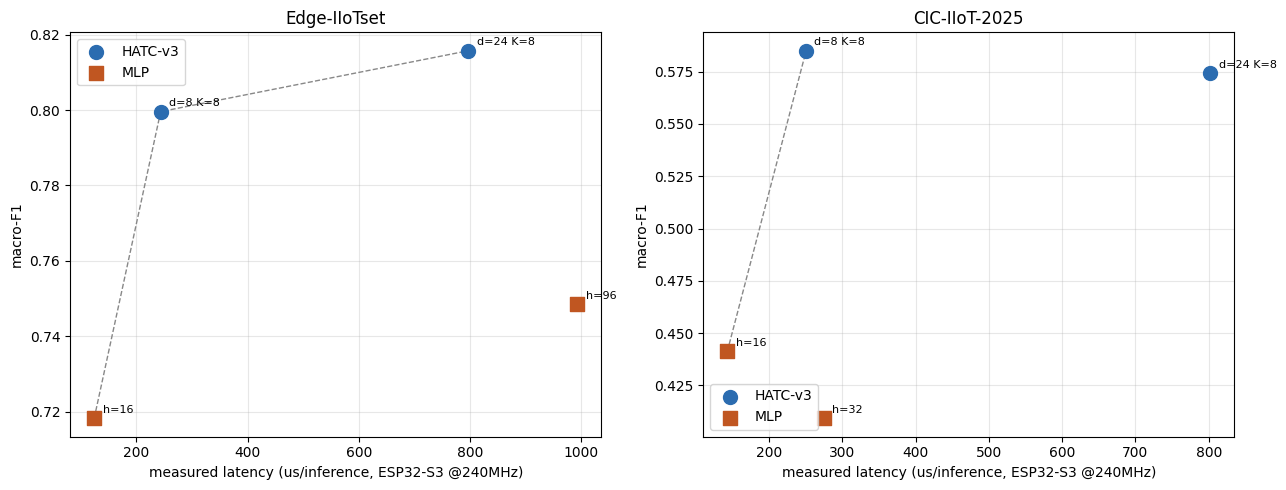

In [119]:
datasets = list(measured.dataset.unique())
fig, axes = plt.subplots(1, len(datasets), figsize=(13, 5), squeeze=False)
for ax, dataset in zip(axes[0], datasets):
    plot_frontier(ax, dataset)
    ax.set_xlabel("measured latency (us/inference, ESP32-S3 @240MHz)")
    ax.set_ylabel("macro-F1")
    ax.set_title(dataset)
    ax.grid(alpha=.3)
    ax.legend()
plt.tight_layout()
plt.show()

In [120]:
for dataset in datasets:
    print(f"{dataset}\n  {frontier_line(consolidated, dataset)}")

Edge-IIoTset
  Pareto-optimal: MLP h=16 -> HATC-v3 d=8 K=8 -> HATC-v3 d=24 K=8.    Dominated: MLP h=96
CIC-IIoT-2025
  Pareto-optimal: MLP h=16 -> HATC-v3 d=8 K=8.    Dominated: MLP h=32, HATC-v3 d=24 K=8


## 13 · Per-class F1, HATC vs MLP

Ranked by the worse of the two models, so shared weak spots surface first.

In [121]:
per_class = pd.read_csv(PERCLASS_CSV)
pivot = per_class.pivot_table(index=["dataset", "cls"], columns="arm", values="f1", aggfunc="mean")
support = per_class.groupby(["dataset", "cls"]).support.first()

In [122]:
for dataset in pivot.index.get_level_values(0).unique():
    print("=" * 78); print(dataset); print("=" * 78)
    view = pivot.loc[dataset].dropna(axis=1, how="all")   # other dataset's arms
    view = view.join(support.loc[dataset].rename("support"))
    print(view.sort_values(view.columns[0]).round(4).to_string())
    print()

CIC-IIoT-2025
            HATC-v3 d=24 K=8  MLP h=32  support
cls                                            
bruteforce            0.3807    0.3357    298.0
benign                0.3976    0.4298   8114.0
ddos                  0.4132    0.3225   3235.0
mitm                  0.5730    0.4336   1262.0
recon                 0.5925    0.5664   5387.0
malware               0.6211    0.4282   1448.0
dos                   0.6998    0.1543   3245.0
web                   0.8557    0.6039    241.0

CICIDS2017
                            HATC-v3 d=24 K=8  MLP h=96  support
cls                                                            
Bot                                   0.0000    0.0000    393.0
Infiltration                          0.0680    0.0680      7.0
Web Attack  Sql Injection            0.0957    0.0100      4.0
PortScan                              0.2598    0.1659    400.0
Web Attack  XSS                      0.2822    0.0247    130.0
Web Attack  Brute Force              0.4047  

In [123]:
calibration = pd.read_csv("results/calibration.csv")
print(calibration.groupby(["dataset", "arm"])[["macro_f1", "calibrated_f1"]].mean().round(4).to_string())

                                macro_f1  calibrated_f1
dataset       arm                                      
CIC-IIoT-2025 HATC-v3 d=24 K=8    0.5667         0.6384
              MLP h=32            0.4093         0.5027
CICIDS2017    HATC-v3 d=24 K=8    0.6209         0.6703
              MLP h=96            0.5861         0.6534
Edge-IIoTset  HATC-v3 d=24 K=8    0.8177         0.8590
              MLP h=96            0.7484         0.8064


## 14 · INT8 quantisation

In [124]:
for dataset in DATASETS:
    if not have(QAT_CSV[dataset]):
        print(f"(missing {QAT_CSV[dataset]})")
        continue
    print("=" * 78); print(LABEL[dataset]); print("=" * 78)
    table = pd.read_csv(QAT_CSV[dataset]).groupby(["config", "mode"])["macro_f1"].mean().unstack()
    for mode in [c for c in table.columns if c != "FP32"]:
        table[f"d{mode}"] = table[mode] - table["FP32"]
    print(table.round(4).to_string())
    print()

Edge-IIoTset
mode                FP32  PTQ-INT8  QAT-INT8  QAT-INT8-pow2  dPTQ-INT8  dQAT-INT8  dQAT-INT8-pow2
config                                                                                           
HATC-v3 d=24 K=8  0.8216    0.8113    0.8191         0.8107    -0.0103    -0.0025         -0.0109
HATC-v3 d=8 K=8   0.7977    0.7852    0.8062         0.7959    -0.0125     0.0086         -0.0018
MLP h=16          0.7182    0.7007    0.7017            NaN    -0.0175    -0.0165             NaN
MLP h=96          0.7484    0.7152    0.7256            NaN    -0.0332    -0.0228             NaN

CIC-IIoT-2025
mode                FP32  PTQ-INT8  QAT-INT8  QAT-INT8-pow2  dPTQ-INT8  dQAT-INT8  dQAT-INT8-pow2
config                                                                                           
HATC-v3 d=24 K=8  0.5671    0.5655    0.5590         0.5536    -0.0016    -0.0081         -0.0135
HATC-v3 d=8 K=8   0.5809    0.5819    0.5169         0.6030     0.0009    -0.0640         

---
# Part C — Hardware (ESP32-S3)

Shells out to the flash scripts — a notebook cannot drive the board directly,
it needs `arduino-cli` and a real serial port. **All cells no-op safely when
no board is attached.**

## 15 · Detect the board

In [125]:
def run_shell(cmd: list[str], log_name: str, timeout: int) -> tuple[int, str]:
    """Run a firmware script, tee its output to logs/, print the tail."""
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    output = (result.stdout or "") + (result.stderr or "")
    open(os.path.join("logs", log_name), "w", encoding="utf-8").write(output)
    print("\n".join(output.strip().split("\n")[-10:]))
    return result.returncode, output

In [126]:
BOARD_MARKERS = ("esp32", "ESP32", "CP210", "CH9102", "FTDI", "USB")


def detect_board_port() -> Optional[str]:
    """Explicit BOARD_PORT wins; else scan `arduino-cli board list`."""
    if BOARD_PORT:
        return BOARD_PORT
    if not os.path.exists(ARDUINO_CLI):
        return None
    listing = subprocess.run([ARDUINO_CLI, "board", "list"], capture_output=True, text=True).stdout
    for line in listing.splitlines():
        token = line.split()[0] if line.split() else ""
        if any(m in line for m in BOARD_MARKERS) and (token.upper().startswith("COM") or token.startswith("/dev/")):
            return token
    return None

In [127]:
PORT = detect_board_port()
print("board port:", PORT or "NOT DETECTED - Part C will skip")

board port: NOT DETECTED - Part C will skip


## 16 · Parity + latency

The critical correctness check: each build runs 1000 real verification flows
on-device and must reproduce the host model's predictions exactly. Expected
**1000/1000**; before the export bias-truncation fix this read 56.2%.

In [128]:
if PORT:
    run_shell(["bash", "firmware/flash_verify.sh", PORT], "flash_verify.log", timeout=1800)
else:
    print("[SKIP] no board")

[SKIP] no board


## 17 · Measured latency frontier

Flashes each exported config and records median latency — this is what turns
the Pareto cost axis from analytic MACs into measured microseconds.

In [129]:
FLASH_CONFIGS = [os.path.basename(p) for p in sorted(
    __import__("glob").glob(os.path.join(FIRMWARE_ROOT, "*"))) if not p.endswith("_original")]
print("exported configs:", *FLASH_CONFIGS, sep="\n  ")

exported configs:
  cic25_hatc_d24_k8
  cic25_hatc_d8_k8
  cic25_mlp_h16
  cic25_mlp_h32
  cicids_hatc_d24_k8
  cicids_hatc_d8_k8
  cicids_mlp_h16
  cicids_mlp_h96
  edge_hatc_d24_k8
  edge_hatc_d8_k8
  edge_mlp_h16
  edge_mlp_h96


In [130]:
def parse_measurement(config: str, output: str) -> dict:
    """Pull parity and median latency out of a flash script's stdout."""
    row = {"config": config}
    for line in output.splitlines():
        if "host-reproduction:" in line:
            row["parity"] = line.split(":", 1)[1].strip()
        if line.startswith("latency: median=") and "us" in line:
            row["median_us"] = float(line.split("median=")[1].split("us")[0])
    return row

In [131]:
if PORT:
    rows = [parse_measurement(c, run_shell(["bash", "firmware/flash_config.sh", c, PORT],
                                            f"measured_{c}.log", timeout=1200)[1])
            for c in FLASH_CONFIGS]
    latency = pd.DataFrame(rows)
    latency.to_csv("results/measured_latency.csv", index=False)
    print(latency.to_string(index=False))
else:
    print("[SKIP] no board — configs that would be measured:", *FLASH_CONFIGS, sep="\n  ")

[SKIP] no board — configs that would be measured:
  cic25_hatc_d24_k8
  cic25_hatc_d8_k8
  cic25_mlp_h16
  cic25_mlp_h32
  cicids_hatc_d24_k8
  cicids_hatc_d8_k8
  cicids_mlp_h16
  cicids_mlp_h96
  edge_hatc_d24_k8
  edge_hatc_d8_k8
  edge_mlp_h16
  edge_mlp_h96


## 18 · Energy

A single inference is ~250–800 µs while affordable USB meters sample at
1–10 Hz, so per-inference energy cannot be read directly. These builds
alternate a **silent** 15 s ACTIVE phase with a 15 s IDLE phase so a slow
meter settles in each:

$$E_\text{inference} = (P_\text{active} - P_\text{idle}) \times t_\text{inference}$$

Read the meter ~2 s into each phase. Serial stays quiet during the measured
phases because UART draw would otherwise dominate the difference.

In [132]:
ENERGY_CONFIGS = [c for c in FLASH_CONFIGS if "hatc_d24" in c or "mlp_h96" in c or "mlp_h32" in c]

if PORT:
    for config in ENERGY_CONFIGS:
        print(f"\n=== {config} — watch the meter, record ACTIVE then IDLE ===")
        run_shell(["bash", "firmware/flash_power.sh", config, PORT], f"power_{config}.log", timeout=900)
else:
    print("[SKIP] no board — energy configs prepared:", *ENERGY_CONFIGS, sep="\n  ")

[SKIP] no board — energy configs prepared:
  cic25_hatc_d24_k8
  cic25_mlp_h32
  cicids_hatc_d24_k8
  cicids_mlp_h96
  edge_hatc_d24_k8
  edge_mlp_h96


---
## Outputs

| path | contents |
|---|---|
| `results/results_*.csv` | per-arm, per-seed accuracy |
| `results/qat_*.csv` | INT8 FP32 / PTQ / QAT / pow2 |
| `results/per_class.csv`, `confusion_matrices.csv`, `calibration.csv` | per-class analysis |
| `results/consolidated_results.csv` | accuracy + cost + measured latency, one row per arm |
| `results/measured_latency.csv` | on-device medians (written by Part C) |
| `firmware/configs/` | exported weight headers per configuration |
| `HATC-IDS_Report.docx` | design + methodology + results, tables generated from the CSVs |
| `logs/` | stdout of every hardware run |

**Carry this caveat into the write-up.** The architectural ablations
(grouped-block classifier quantisation, piecewise embedding, and two negative
results) were run on TON_IoT only. They are design rationale, not evidence,
for the two datasets reported here.